In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar los datos
df = pd.read_csv("C:\\Users\\eulal\\OneDrive\\Escritorio\\laloseasontwo\\Minería de datos\\Data Cleaning\\netflix_titles.csv")
# Estadísticas descriptivas básicas
print("Información del dataset:")
print(df.info())

print("\nEstadísticas descriptivas para columnas numéricas:")
print(df.describe())

print("\nValores únicos por columna categórica:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].nunique()} valores únicos")

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

Estadísticas descriptivas para columnas numéricas:
       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     20

Asi es como dejare mis entidades para este modelo de datos:
Tomado de practica #2


In [5]:
import pandas as pd
from itertools import chain

# 1. Tabla CONTENIDO
contenido = df[['show_id', 'title', 'type', 'date_added', 'release_year', 'rating', 'description']]

# 2. Tabla PERSONA (directores y actores)
# Para directores
directores = df['director'].str.split(', ', expand=True).stack().reset_index(drop=True).to_frame('nombre')
directores['tipo'] = 'director'

# Para actores
actores = df['cast'].str.split(', ', expand=True).stack().reset_index(drop=True).to_frame('nombre')
actores['tipo'] = 'actor'

# Combinar
personas = pd.concat([directores, actores]).drop_duplicates().reset_index(drop=True)
personas['persona_id'] = personas.index + 1

# 3. Tabla PAÍS
paises = df['country'].str.split(', ', expand=True).stack().reset_index(drop=True).to_frame('nombre')
paises = paises.drop_duplicates().reset_index(drop=True)
paises['pais_id'] = paises.index + 1

# 4. Tabla GÉNERO
generos = df['listed_in'].str.split(', ', expand=True).stack().reset_index(drop=True).to_frame('nombre')
generos = generos.drop_duplicates().reset_index(drop=True)
generos['genero_id'] = generos.index + 1

In [6]:
# Tabla DIRIGE (relación entre contenido y directores)
dirige = (
    df['director'].str.split(', ', expand=True)
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'show_idx', 0: 'nombre'})
)
dirige = pd.merge(
    dirige,
    personas[personas['tipo'] == 'director'],
    on='nombre',
    how='left'
)[['show_idx', 'persona_id']]
dirige['show_id'] = df.loc[dirige['show_idx'], 'show_id'].values

# Tabla ACTUA (relación entre contenido y actores)
actua = (
    df['cast'].str.split(', ', expand=True)
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'show_idx', 0: 'nombre'})
)
actua = pd.merge(
    actua,
    personas[personas['tipo'] == 'actor'],
    on='nombre',
    how='left'
)[['show_idx', 'persona_id']]
actua['show_id'] = df.loc[actua['show_idx'], 'show_id'].values

# Tabla PRODUCIDO_EN (relación entre contenido y países)
producido = (
    df['country'].str.split(', ', expand=True)
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'show_idx', 0: 'nombre'})
)
producido = pd.merge(
    producido,
    paises,
    on='nombre',
    how='left'
)[['show_idx', 'pais_id']]
producido['show_id'] = df.loc[producido['show_idx'], 'show_id'].values

# Tabla CLASIFICADO (relación entre contenido y géneros)
clasificado = (
    df['listed_in'].str.split(', ', expand=True)
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'show_idx', 0: 'nombre'})
)
clasificado = pd.merge(
    clasificado,
    generos,
    on='nombre',
    how='left'
)[['show_idx', 'genero_id']]
clasificado['show_id'] = df.loc[clasificado['show_idx'], 'show_id'].values

En esta sección voy a explorar la relación entre el año de lanzamiento y la duración del contenido (minutos), ajustando un modelo de regresión lineal.

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar solo contenido tipo 'Movie' y eliminar nulos en la columna 'duration'
df_filtrado = df[df['type'] == 'Movie'].copy()
df_filtrado = df_filtrado[df_filtrado['duration'].notna()]  # <- Eliminamos NaNs
df_filtrado = df_filtrado[df_filtrado['duration'].str.contains('min')]

# Extraer la duración en minutos como entero
df_filtrado['duration_minutes'] = df_filtrado['duration'].str.extract('(\d+)').astype(int)

# Mantener solo las columnas necesarias
df_filtrado = df_filtrado[['release_year', 'duration_minutes']].dropna()


<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\eulal\AppData\Local\Temp\ipykernel_29224\1748236682.py:12: SyntaxWarning: invalid escape sequence '\d'
  df_filtrado['duration_minutes'] = df_filtrado['duration'].str.extract('(\d+)').astype(int)


Después de verificar que hay una correlación moderada entre las variables, entreno el modelo lineal y visualizo la línea de ajuste.


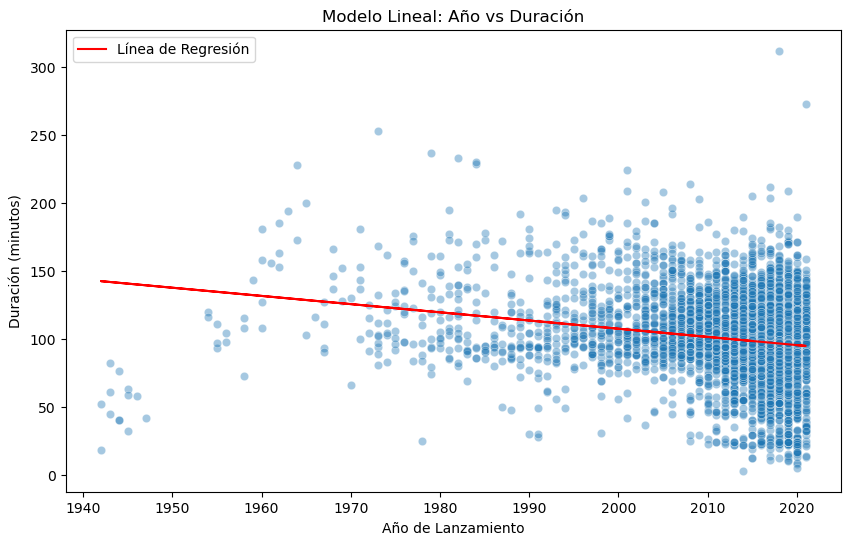

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df_filtrado[['release_year']]
y = df_filtrado['duration_minutes']

modelo = LinearRegression()
modelo.fit(X, y)

y_pred = modelo.predict(X)

plt.figure(figsize=(10,6))
sns.scatterplot(x=df_filtrado['release_year'], y=df_filtrado['duration_minutes'], alpha=0.4)
plt.plot(df_filtrado['release_year'], y_pred, color='red', label='Línea de Regresión')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Duración (minutos)')
plt.title('Modelo Lineal: Año vs Duración')
plt.legend()
plt.show()


In [10]:
r2 = r2_score(y, y_pred)
print("R² del modelo:", r2)


R² del modelo: 0.04255339677044945
